In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import io
import astropy.io.fits
import src.downloadCutout as downloadCutout
import src.downloadPsf as downloadPsf

from astropy.visualization import simple_norm
from astropy.modeling.models import Sersic2D
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
import time
import statmorph
import warnings
from tqdm import tqdm
from joblib import Parallel, delayed
np.random.seed(42)

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0310_dps.fits')
nbcs_df, model_1comp_nbcs, left_2comp_nbcs, right_2comp_nbcs = DP.extract_fits_data('./catalogs/0310_nbcs.fits')

In [3]:
random_indices_dps = np.random.choice(dps_df.index, size=1000, replace=False)
random_indices_nbcs = np.random.choice(nbcs_df.index, size=1000, replace=False)

dps_df = dps_df.loc[random_indices_dps]
nbcs_df = nbcs_df.loc[random_indices_nbcs]

In [4]:
user = 'hyp0515'
password = 'PHFrCTavyczTCw/onxRGH537qhiLWqYSRuHB6WHE'
filter = 'HSC-R'

In [5]:
def morph_classify(df):
    rects_cutout = []
    rects_psf = []
    for ra, dec in zip(df['RA'], df['DEC']):
        rect = downloadCutout.Rect.create(
            ra=	ra,
            dec=dec,
            sw="15arcsec",
            sh="15arcsec",
            variance=True,
            mask=True,
            filter=filter,
        )
        rects_cutout.append(rect)
        
        psfreq = downloadPsf.PsfRequest.create(
            ra=ra,
            dec=dec,
            filter=filter
        )
        rects_psf.append(psfreq)
    images = downloadCutout.download(rects_cutout, user=user, password=password)
    psfs = downloadPsf.download(rects_psf, user=user, password=password)
    Sersic_list = []
    M20_list = []
    Gini_list = []
    C_list = []
    A_list = []
    S_list = []
    As_list = []
    flag_list = []

    def process_image(image_item, psf_item):
        """
        Processes a single image and its corresponding PSF to extract morphological properties.
        Returns a tuple of morphological properties or None on failure.
        """
        if not image_item or not psf_item:
            return None

        try:
            # Unpack and process image data
            _, image_data = image_item[0]
            image_hdu = astropy.io.fits.open(io.BytesIO(image_data))
            image = image_hdu[1].data
            mask = image_hdu[2].data
            var = image_hdu[3].data

            # Unpack and process PSF data
            _, psf_data = psf_item[0]
            psf_hdu = astropy.io.fits.open(io.BytesIO(psf_data))
            psf = psf_hdu[0].data

            # Source detection and segmentation
            threshold = detect_threshold(image, 10)
            npixels = 200  # minimum number of connected pixels
            segmap = detect_sources(image, threshold, npixels)
            if segmap is None:
                return None
            segmap = segmap.data
            # Isolate the central source
            center_val = segmap[int(segmap.shape[0]/2), int(segmap.shape[1]/2)]
            if center_val == 0: # No source at the center
                return None
            segmap = np.where(segmap != center_val, 0, 1)

            # Create a new mask based on segmentation and original mask
            new_mask = np.zeros_like(mask, dtype=bool)
            segmap_zero_indices = (segmap == 0)
            image_segmap_one_max = np.max(image[segmap == 1])
            mask_segmap_zero_min = np.min(mask[segmap_zero_indices])
            mask_segmap_zero_std = np.std(mask.flatten())
            
            new_mask[segmap == 1] = False
            new_mask[segmap_zero_indices] = np.where(
                (mask[segmap_zero_indices] >= mask_segmap_zero_min + mask_segmap_zero_std) |
                (image[segmap_zero_indices] >= image_segmap_one_max * 2/3),
                True, False
            )

            # Run statmorph, catching warnings and exceptions
            with warnings.catch_warnings(record=True) as w:
                warnings.simplefilter("always")
                source_morphs = statmorph.source_morphology(
                    image=image, segmap=segmap, psf=psf, weightmap=np.sqrt(var), mask=new_mask
                )
                if w:  # If any warning was issued, consider it a failure
                    return None
            
            morph = source_morphs[0]
            
            # Return successful results
            return (
                morph.sersic_n, morph.m20, morph.gini,
                morph.concentration, morph.asymmetry, morph.smoothness, morph.shape_asymmetry
            )

        except Exception:
            # Catch any other exceptions during processing
            return None

    # Use joblib to parallelize the processing
    # n_jobs=-1 uses all available CPU cores
    results = Parallel(n_jobs=10)(
        delayed(process_image)(img, psf) for img, psf in tqdm(zip(images, psfs), total=len(images))
    )

    # Unpack the results and populate the lists
    for i, result in enumerate(results):
        if result is not None:
            Sersic_list.append(result[0])
            M20_list.append(result[1])
            Gini_list.append(result[2])
            C_list.append(result[3])
            A_list.append(result[4])
            S_list.append(result[5])
            As_list.append(result[6])
            flag_list.append(True)
        else:
            flag_list.append(False)
    
    morph_df = pd.DataFrame({
        'TARGETID': df['TARGETID'][flag_list],
        'RA': df['RA'][flag_list],
        'DEC': df['DEC'][flag_list],
        'Sersic': Sersic_list,
        'M20': M20_list,
        'Gini': Gini_list,
        'Concentration': C_list,
        'Asymmetry': A_list,
        'Smoothness': S_list,
        'Shape_Asymmetry': As_list
    })
    return morph_df


In [6]:
morph_dps = morph_classify(dps_df)
morph_dps.to_csv('./catalogs/morph_dps.csv', index=False)
morph_nbcs = morph_classify(nbcs_df)
morph_nbcs.to_csv('./catalogs/morph_nbcs.csv', index=False)

100%|██████████| 1000/1000 [00:26<00:00, 37.54it/s]


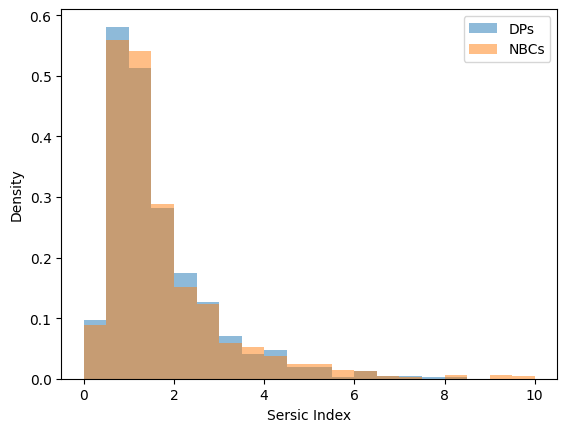

In [11]:
plt.hist(morph_dps['Sersic'], bins=20, alpha=0.5, label='DPs', range=(0, 10), density=True)
plt.hist(morph_nbcs['Sersic'], bins=20, alpha=0.5, label='NBCs', range=(0, 10), density=True)
plt.xlabel('Sersic Index')
plt.ylabel('Density')
plt.legend()
plt.show()

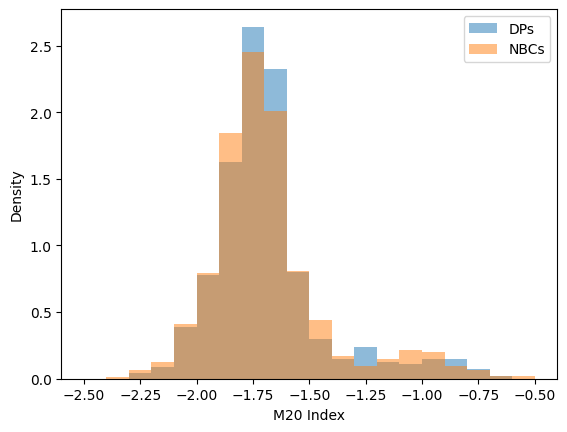

In [12]:
plt.hist(morph_dps['M20'], bins=20, alpha=0.5, label='DPs', range=(-2.5, -0.5), density=True)
plt.hist(morph_nbcs['M20'], bins=20, alpha=0.5, label='NBCs', range=(-2.5, -0.5), density=True)
plt.xlabel('M20 Index')
plt.ylabel('Density')
plt.legend()
plt.show()

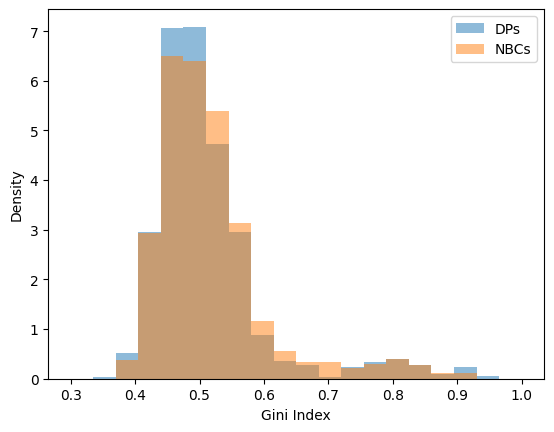

In [15]:
plt.hist(morph_dps['Gini'], bins=20, alpha=0.5, label='DPs', range=(0.3, 1), density=True)
plt.hist(morph_nbcs['Gini'], bins=20, alpha=0.5, label='NBCs', range=(0.3, 1), density=True)
plt.xlabel('Gini Index')
plt.ylabel('Density')
plt.legend()
plt.show()

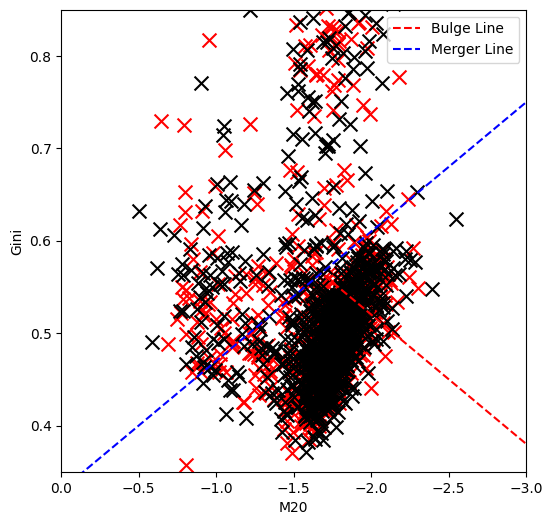

In [18]:
x = np.linspace(0, -3, 100)
merger_line = -0.14 * x + 0.33
bulge_line = 0.14 * x + 0.8
plt.figure(figsize=(6, 6))
plt.scatter(morph_dps['M20'], morph_dps['Gini'], s=100, color='r', marker='x')
plt.scatter(morph_nbcs['M20'], morph_nbcs['Gini'], s=100, color='k', marker='x')
plt.plot(x[bulge_line<merger_line], bulge_line[bulge_line<merger_line], color='red', linestyle='--', label='Bulge Line')
plt.plot(x, merger_line, color='blue', linestyle='--', label='Merger Line')
plt.xlim((0, -3))
plt.ylim((0.35, 0.85))
plt.xlabel('M20')
plt.ylabel('Gini')
plt.legend()
plt.show()